---
title: "Mengenal {EconML}: Menggabungkan Ekonometrika & Machine Learning untuk Estimasi Efek Kausal"
description: "Tutorial singkat memakai Python package {EconML} dengan contoh data e-commerce Indonesia"
date: 2025-07-19
author: Deri Siswara
toc: true
categories:
  - Python
  - Ekonometrika
  - Machine Learning
---

## Pendahuluan

`EconML` adalah pustaka Python dari Microsoft Research yang mempermudah estimasi *heterogeneous treatment effects* (HTE) pada data observasional maupun eksperimen—mengombinasikan teknik ekonometrika klasik dengan *machine learning* modern untuk analisis kausal yang lebih otomatis dan fleksibel. ([PyPI](https://pypi.org/project/econml/)) Paket ini terus diperbarui; rilis terbaru menambahkan fitur *treatment featurization*, sub-paket panel, dan perbaikan bug penting. ([GitHub](https://github.com/py-why/EconML))

Singkatnya, `EconML` menyediakan berbagai estimator seperti **Double Machine Learning (DML)**, **Doubly Robust Learner (DR)**, **Meta-Learners (T/S/X-Learner)**, dan **Orthogonal Random Forest (ORF)**, lengkap dengan API yang konsisten untuk inferensi kausal.

Tutorial ini memperkenalkan *explainable AI* melalui perspektif *causal machine learning* menggunakan EconML. Berbeda dengan model ML yang berfokus pada prediksi, Causal ML bertujuan memahami *mengapa* suatu outcome terjadi dengan mengestimasi efek kausal dan memungkinkan simulasi skenario "what-if".

### Instalasi

```bash
# pastikan Python ≥3.9
pip install econml scikit-learn pandas numpy matplotlib seaborn lightgbm
```

## Studi Kasus: Efek Kausal Notifikasi Dynamic Pricing di E-commerce Indonesia

### Pertanyaan Penelitian:

Bagaimana efek kausal dari notifikasi dynamic pricing terhadap jumlah transaksi konsumen selama periode flash sale di platform e-commerce Indonesia?

### Problem

Kita tidak dapat menjalankan A/B test tradisional dengan memaksa sebagian konsumen menerima notifikasi dynamic pricing dan yang lain tidak. Perilaku opt-out adalah self-selected, artinya konsumen memutuskan berdasarkan karakteristik mereka:

- Konsumen yang tidak sensitif harga atau memiliki kebutuhan mendesak mungkin menerima notifikasi
- Konsumen yang sensitif harga atau dalam situasi non-urgent lebih cenderung opt-out

Hal ini menimbulkan selection bias, membuat perbandingan sederhana antara grup opt-out dan non-opt-out tidak reliable.

### Solusi dengan EconML

Misalkan platform e-commerce Indonesia sebelumnya melakukan eksperimen yang secara random menugaskan pengguna ke versi prompt opt-out yang berbeda:

- "Apakah Anda yakin?" (confirmation step) [lebih sulit]  
- "One-click toggle" (simplified opt-out) [lebih mudah]

Varian prompt ini menciptakan variasi random dalam likelihood opt-out dan dapat berfungsi sebagai instrumental variable (IV). Kita akan menggunakan **Intent-To-Treat Doubly Robust Instrumental Variable estimator (DRIV)** dari EconML untuk memahami hubungan kausal ini.

In [9]:
import shap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings 
warnings.filterwarnings("ignore")
import os
import sys

#ML packages
import lightgbm as lgb
from sklearn.utils import resample
from sklearn.preprocessing import PolynomialFeatures

#EconMl
from econml.iv.dr import IntentToTreatDRIV
from econml.iv.dr import LinearIntentToTreatDRIV
from econml.cate_interpreter import SingleTreeCateInterpreter, SingleTreePolicyInterpreter

## Setup & Simulasi Data

Karena kita tidak memiliki data yang tersedia, kita akan membuat data sintetis dengan 100.000 observasi menggunakan konteks e-commerce Indonesia untuk mendemonstrasikan kemampuan EconML.

In [10]:
# Set seed untuk reproducibility
np.random.seed(42)

# Sample size 
n = 100000

# Data simulasi dengan konteks Indonesia
data = pd.DataFrame({
    "transaksi_flashsale_pre": np.random.poisson(2, size=n),
    "total_transaksi_pre": np.random.poisson(8, size=n),
    "avg_spending_pre": np.round(np.random.normal(150_000, 50_000, size=n), 0),  # Rupiah
    "kota_pengguna": np.random.choice(["Jakarta", "Surabaya", "Bandung", "Medan", "Makassar", "Yogyakarta"], size=n),
    "platform_device": np.random.choice(["Android", "iOS", "Web"], size=n, p=[0.6, 0.3, 0.1]),
    "is_premium_member": np.random.choice([0, 1], size=n, p=[0.75, 0.25]),
    "prompt_variant_mudah": np.random.choice([0, 1], size=n)  # Instrument
})

# Simulasi treatment assignment berdasarkan instrument dengan noise
data["opted_out_notif"] = np.where(
    (data["prompt_variant_mudah"] == 1) & (np.random.rand(n) < 0.65), 1,
    np.where((data["prompt_variant_mudah"] == 0) & (np.random.rand(n) < 0.35), 1, 0)
)

# Simulasi post-treatment behavior dengan treatment effect
data["transaksi_flashsale_post"] = (
    data["transaksi_flashsale_pre"] + 
    np.random.normal(0, 0.8, size=n) +
    1.2 * (1 - data["opted_out_notif"])  # Users yang tidak opt-out melakukan lebih banyak transaksi
).round().astype(int)

# Pastikan tidak ada transaksi negatif
data["transaksi_flashsale_post"] = data["transaksi_flashsale_post"].clip(lower=0)

# Buat direktori jika belum ada
os.makedirs('analysis', exist_ok=True)

# Simpan ke CSV
data.to_csv('analysis/ecommerce_indonesia_data.csv', index=False)

# Tampilkan beberapa baris pertama
data.head()

,transaksi_flashsale_pre,total_transaksi_pre,avg_spending_pre,kota_pengguna,platform_device,is_premium_member,prompt_variant_mudah,opted_out_notif,transaksi_flashsale_post
0,4,5,204612.0,Medan,iOS,1,1,1,4
1,1,8,129046.0,Yogyakarta,iOS,0,0,0,2
2,3,5,112036.0,Surabaya,Android,0,1,0,4
3,3,15,115106.0,Bandung,Android,0,0,0,4
4,1,8,206403.0,Medan,Android,0,1,1,1


## Analisis Data Eksploratori

Dengan data yang sudah dibuat, kita dapat mengeksplorasi distribusi fitur dan mengimplementasikan model EconML.

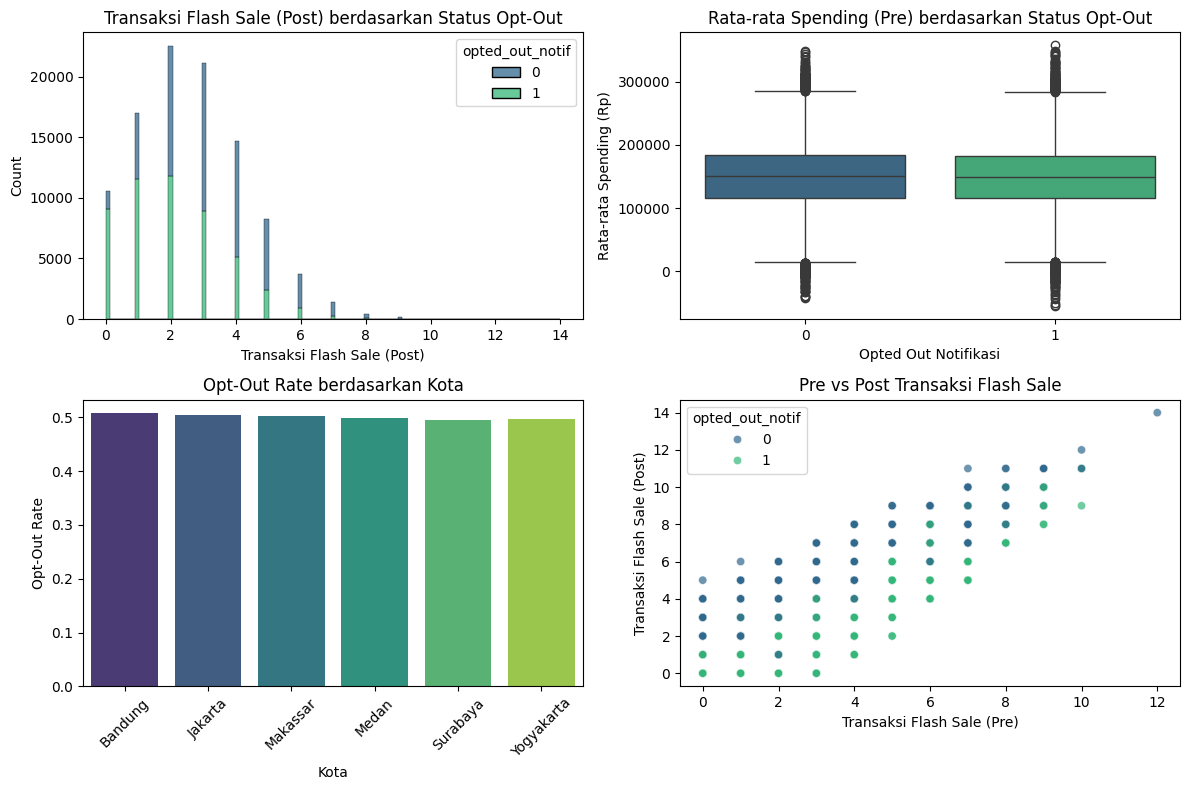

In [11]:
# Set up subplot grid
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1: Distribusi Transaksi Flash Sale Post berdasarkan Status Opt-Out
sns.histplot(data, x="transaksi_flashsale_post", hue="opted_out_notif", 
             multiple="stack", ax=axes[0, 0], palette="viridis")
axes[0, 0].set_title("Transaksi Flash Sale (Post) berdasarkan Status Opt-Out")
axes[0, 0].set_xlabel("Transaksi Flash Sale (Post)")
axes[0, 0].set_ylabel("Count")

# Plot 2: Boxplot Average Spending berdasarkan Status Opt-Out
sns.boxplot(data=data, x="opted_out_notif", y="avg_spending_pre", 
            ax=axes[0, 1], palette="viridis")
axes[0, 1].set_title("Rata-rata Spending (Pre) berdasarkan Status Opt-Out")
axes[0, 1].set_xlabel("Opted Out Notifikasi")
axes[0, 1].set_ylabel("Rata-rata Spending (Rp)")

# Plot 3: Opt-Out Rate berdasarkan Kota
city_opt_out = data.groupby("kota_pengguna")["opted_out_notif"].mean().reset_index()
sns.barplot(data=city_opt_out, x="kota_pengguna", y="opted_out_notif", 
            ax=axes[1, 0], palette="viridis")
axes[1, 0].set_title("Opt-Out Rate berdasarkan Kota")
axes[1, 0].set_xlabel("Kota")
axes[1, 0].set_ylabel("Opt-Out Rate")
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: Scatter Plot Pre vs Post Flash Sale Transactions
sns.scatterplot(data=data, x="transaksi_flashsale_pre", y="transaksi_flashsale_post", 
                hue="opted_out_notif", alpha=0.7, ax=axes[1, 1], palette="viridis")
axes[1, 1].set_title("Pre vs Post Transaksi Flash Sale")
axes[1, 1].set_xlabel("Transaksi Flash Sale (Pre)")
axes[1, 1].set_ylabel("Transaksi Flash Sale (Post)")

plt.tight_layout()
plt.show()

**Key insights dari data:**

- Transaksi flash sale post lebih tinggi di antara pengguna yang tidak opt-out dari notifikasi dynamic pricing
- Average spending serupa di seluruh grup opt-out, menunjukkan level spending saja mungkin tidak mendorong perilaku opt-out  
- Opt-out rate bervariasi sedikit berdasarkan kota, dengan tidak ada kota yang menunjukkan deviasi ekstrem
- Ada hubungan positif antara transaksi flash sale pre dan post, dan lebih kuat untuk pengguna yang tidak opt-out

## Implementasi EconML: Intent-To-Treat DRIV

Setelah mengeksplorasi data, kita implementasikan estimator **IntentToTreatDRIV** dari EconML. Estimator ini cocok untuk situasi dimana kita memiliki instrumental variable dan ingin mengestimasi efek kausal dengan robust terhadap model misspecification.

Untuk memastikan model dapat berjalan sukses, kita melakukan preprocessing dengan One-hot encoding untuk fitur kategorikal.

In [12]:
# One-hot encode variabel kategorikal
data_encoded = pd.get_dummies(data, columns=["kota_pengguna", "platform_device"])

In [13]:
# Definisikan instrument, treatment, dan outcome
Z = data_encoded['prompt_variant_mudah']  # Instrument
T = data_encoded['opted_out_notif']       # Treatment
Y = data_encoded['transaksi_flashsale_post']  # Outcome

# Definisikan fitur (excludes instrument, treatment, dan outcome)
X = data_encoded.drop(columns=['prompt_variant_mudah', 'opted_out_notif', 'transaksi_flashsale_post'])

In [14]:
# Definisikan nuisance models
lgb_T_XZ_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.1,
    'num_leaves': 30,
    'max_depth': 5,
    'verbosity': -1
}

lgb_Y_X_params = {
    'metric': 'rmse',
    'learning_rate': 0.1,
    'num_leaves': 30,
    'max_depth': 5,
    'verbosity': -1
}

model_T_XZ = lgb.LGBMClassifier(**lgb_T_XZ_params)
model_Y_X = lgb.LGBMRegressor(**lgb_Y_X_params)
flexible_model_effect = lgb.LGBMRegressor(**lgb_Y_X_params)

In [15]:
# Train EconML model menggunakan IntentToTreatDRIV
causal_model = IntentToTreatDRIV(
    model_y_xw=model_Y_X,
    model_t_xwz=model_T_XZ,
    flexible_model_effect=flexible_model_effect
)

# Fit model
causal_model.fit(Y, T, Z=Z, X=X)

In [16]:
# Dapatkan causal effect
causal_effect = causal_model.effect(X)
print("Efek Kausal Opt-Out Notifikasi terhadap Transaksi Flash Sale:", causal_effect.mean())
print("Contoh efek individual (8 konsumen pertama):")
print(causal_effect[:8])

Efek Kausal Opt-Out Notifikasi terhadap Transaksi Flash Sale: -1.185807532351828
Contoh efek individual (8 konsumen pertama):
[-0.87303727 -1.22304944 -1.25669634 -1.01695346 -1.11184453 -1.25628156
 -1.49156137 -1.23645329]


## Interpretasi Hasil

Efek kausal yang diestimasikan adalah negatif, menunjukkan bahwa opt-out dari notifikasi dynamic pricing menghasilkan lebih sedikit transaksi selama flash sale. 

**Implikasi bisnis:**
- Notifikasi kemungkinan mendorong pengguna untuk lebih engage selama flash sale
- Price visibility memicu keputusan yang time-sensitive  
- Untuk pengguna yang opt-out, diperlukan insentif alternatif seperti loyalty points atau cashback

Ini mendemonstrasikan kekuatan EconML dalam mengungkap insight kausal yang tidak bisa didapat dari analisis korelasi biasa.

## Heterogeneous Treatment Effects dengan EconML

Salah satu keunggulan EconML adalah kemampuannya menganalisis heterogeneous treatment effects—apakah efek kausal berbeda antar subgroup. Kita gunakan `SingleTreeCateInterpreter` untuk memahami variasi ini.

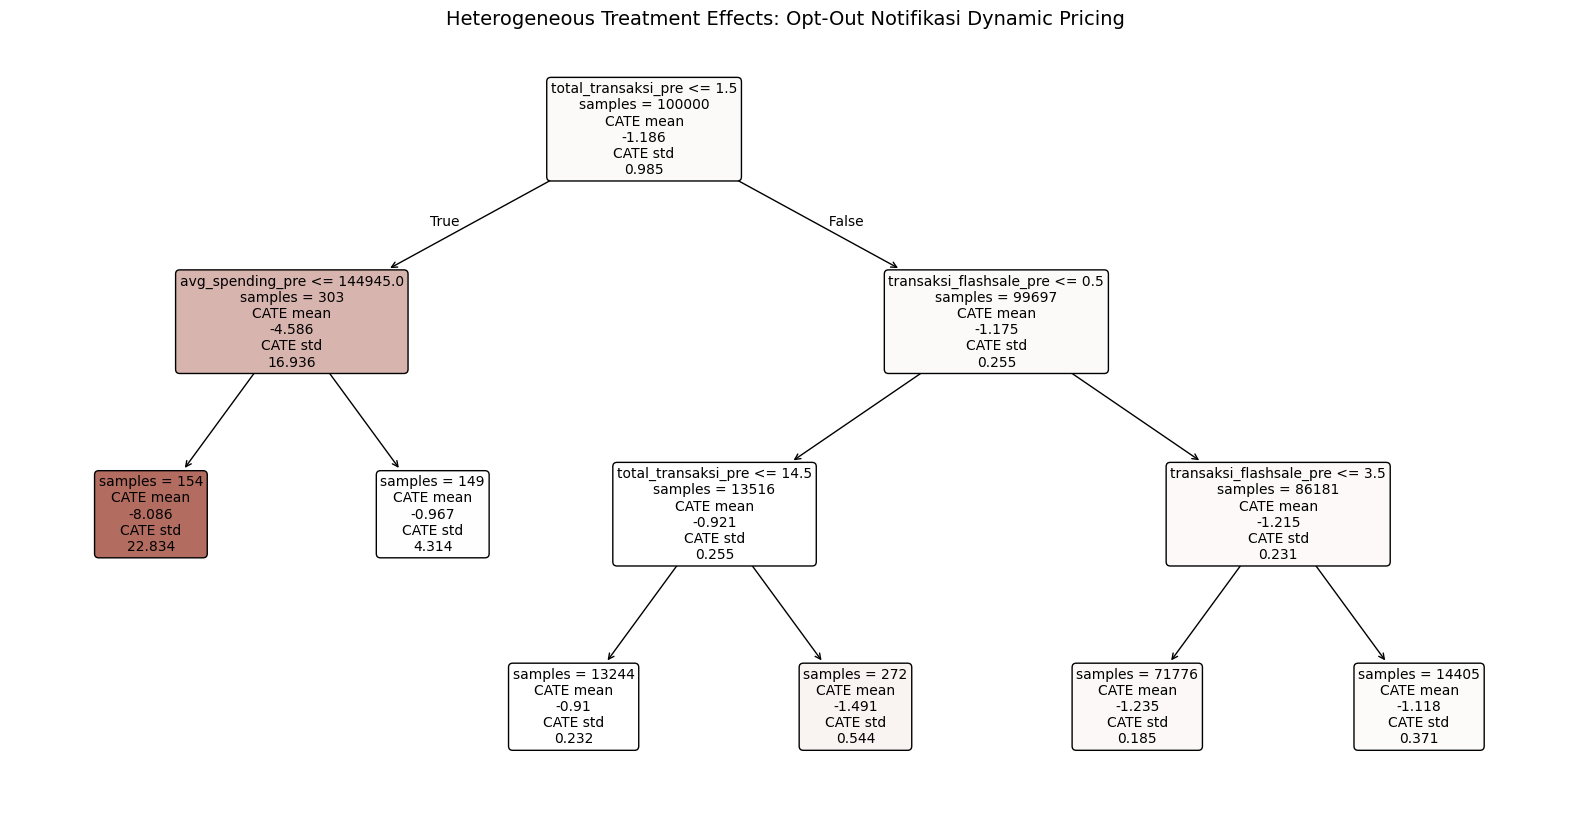

In [17]:
# Gunakan SingleTreeCateInterpreter untuk interpretasi treatment effects
intrp = SingleTreeCateInterpreter(max_depth=3, min_samples_leaf=100)
intrp.interpret(causal_model, X)

# Plot decision tree
plt.figure(figsize=(20, 10))
intrp.plot(feature_names=X.columns, fontsize=10)
plt.title("Heterogeneous Treatment Effects: Opt-Out Notifikasi Dynamic Pricing", fontsize=14)
plt.show()

## Kesimpulan & Rekomendasi

Analisis menggunakan EconML mengungkapkan bahwa:

1. **Efek kausal rata-rata negatif**: Opt-out notifikasi mengurangi transaksi flash sale
2. **Heterogenitas signifikan**: Efek berbeda antar segmen pengguna  
3. **Targeted intervention lebih optimal**: One-size-fits-all approach sub-optimal

**Rekomendasi implementasi:**
- **Segmentasi berbasis perilaku**: Identifikasi high-frequency vs casual shoppers
- **Targeted messaging**: Kirim notifikasi hanya ke segmen responsif
- **Alternative incentives**: Cashback/loyalty points untuk yang opt-out
- **Regional customization**: Pertimbangkan perbedaan perilaku antar kota

EconML memungkinkan data scientist dan business analyst untuk tidak hanya memprediksi, tapi juga memahami mekanisme kausal dan merancang intervensi yang lebih efektif.

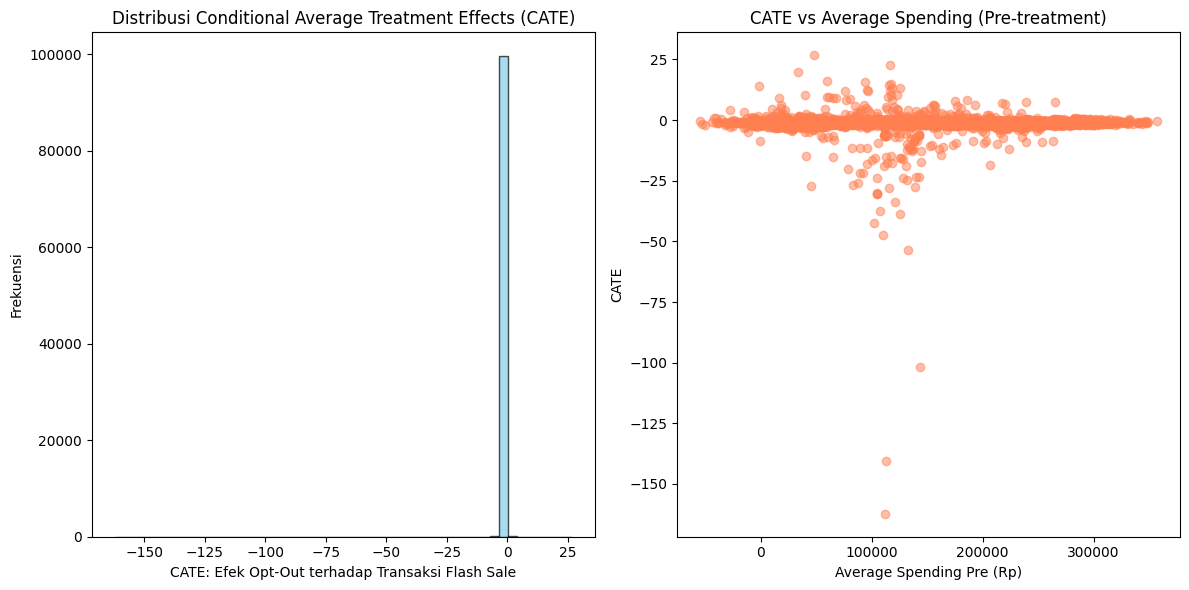

In [18]:
# Visualisasi distribusi CATE untuk better understanding
plt.figure(figsize=(12, 6))

# Plot distribusi CATE
plt.subplot(1, 2, 1)
plt.hist(causal_effect, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title("Distribusi Conditional Average Treatment Effects (CATE)")
plt.xlabel("CATE: Efek Opt-Out terhadap Transaksi Flash Sale")
plt.ylabel("Frekuensi")

# Plot CATE vs spending behavior
plt.subplot(1, 2, 2)
plt.scatter(X['avg_spending_pre'], causal_effect, alpha=0.5, color='coral')
plt.title("CATE vs Average Spending (Pre-treatment)")
plt.xlabel("Average Spending Pre (Rp)")
plt.ylabel("CATE")

plt.tight_layout()
plt.show()

## Langkah Selanjutnya dengan EconML

Tutorial ini hanya menyentuh sebagian kecil kemampuan EconML. Untuk eksplorasi lebih lanjut:

- **Double Machine Learning (DML)** untuk treatment effects dengan confounders
- **Meta-Learners** (T/S/X-Learner) untuk berbagai skenario treatment
- **Orthogonal Random Forest** untuk non-parametric CATE estimation
- **Policy Learning** untuk optimal treatment assignment

EconML documentation: [econml.azurewebsites.net](https://econml.azurewebsites.net)